# 📊 YouTube Top Channels Analysis

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


In [2]:

df = pd.read_csv('youtube_top_50_by_subscribers.csv')
df.head()


,rank,channel,subscribers,video_views,uploads
0,1,MrBeast,474M,116.11B,956
1,2,T-Series,311M,335.8B,25.76K
2,3,Cocomelon - Nursery Rhymes,200M,219.43B,1.96K
3,4,YouTube Movies,197M,0,0
4,5,SET India,189M,187.23B,168.42K


## Data Cleaning

In [3]:

df['subscribers'] = df['subscribers'].str.replace('M','').astype(float)

df['video_views'] = df['video_views'].str.replace('B','').str.replace('M','')
df['video_views'] = pd.to_numeric(df['video_views'], errors='coerce')

df['uploads'] = df['uploads'].str.replace('K','')
df['uploads'] = pd.to_numeric(df['uploads'], errors='coerce')

df.head()


,rank,channel,subscribers,video_views,uploads
0,1,MrBeast,474.0,116.11,956.00
1,2,T-Series,311.0,335.80,25.76
2,3,Cocomelon - Nursery Rhymes,200.0,219.43,1.96
3,4,YouTube Movies,197.0,0.00,0.00
4,5,SET India,189.0,187.23,168.42


## Top Channels by Subscribers

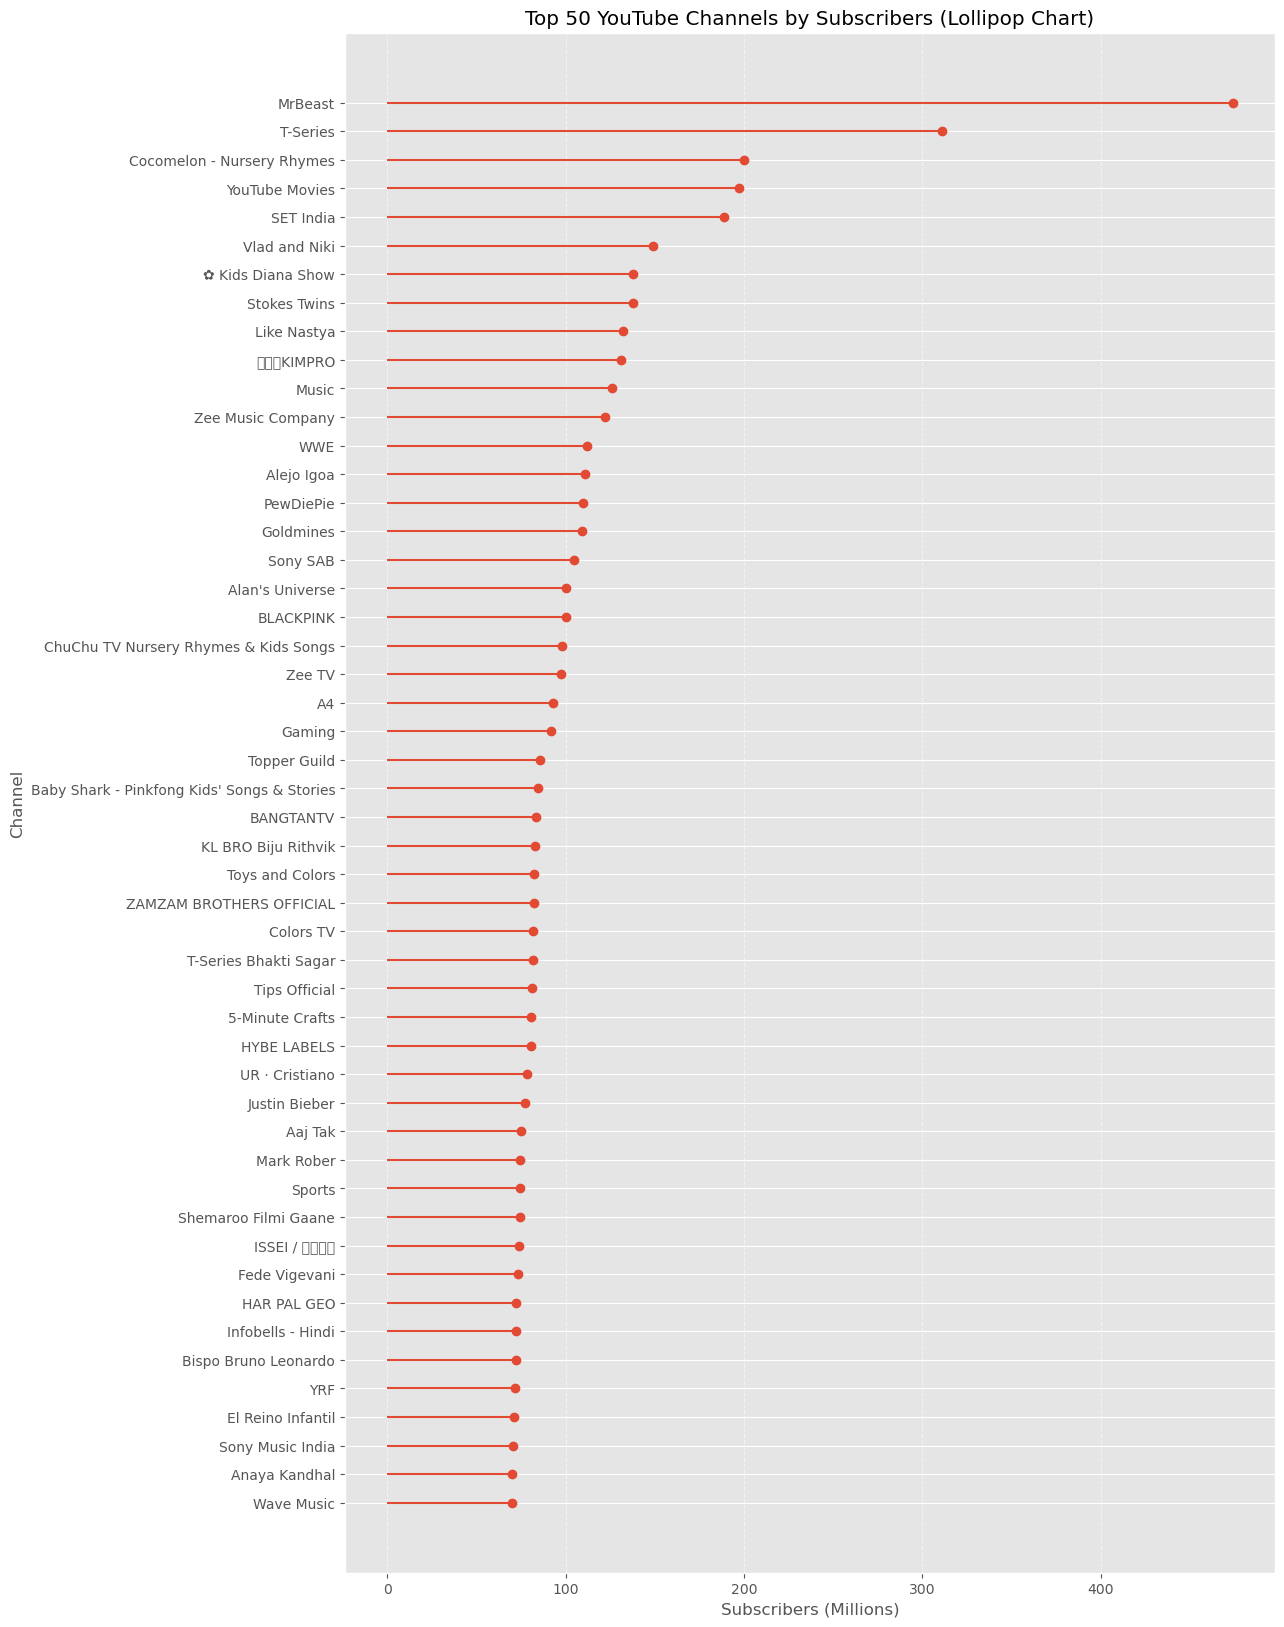

In [12]:
df_sorted = df.sort_values(by='subscribers', ascending=True)

plt.figure(figsize=(12,20))

plt.hlines(y=df_sorted['channel'], xmin=0, xmax=df_sorted['subscribers'])
plt.plot(df_sorted['subscribers'], df_sorted['channel'], "o")

plt.title("Top 50 YouTube Channels by Subscribers (Lollipop Chart)")
plt.xlabel("Subscribers (Millions)")
plt.ylabel("Channel")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12387 (\N{HIRAGANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12379 (\N{HIRAGANA LETTER SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s

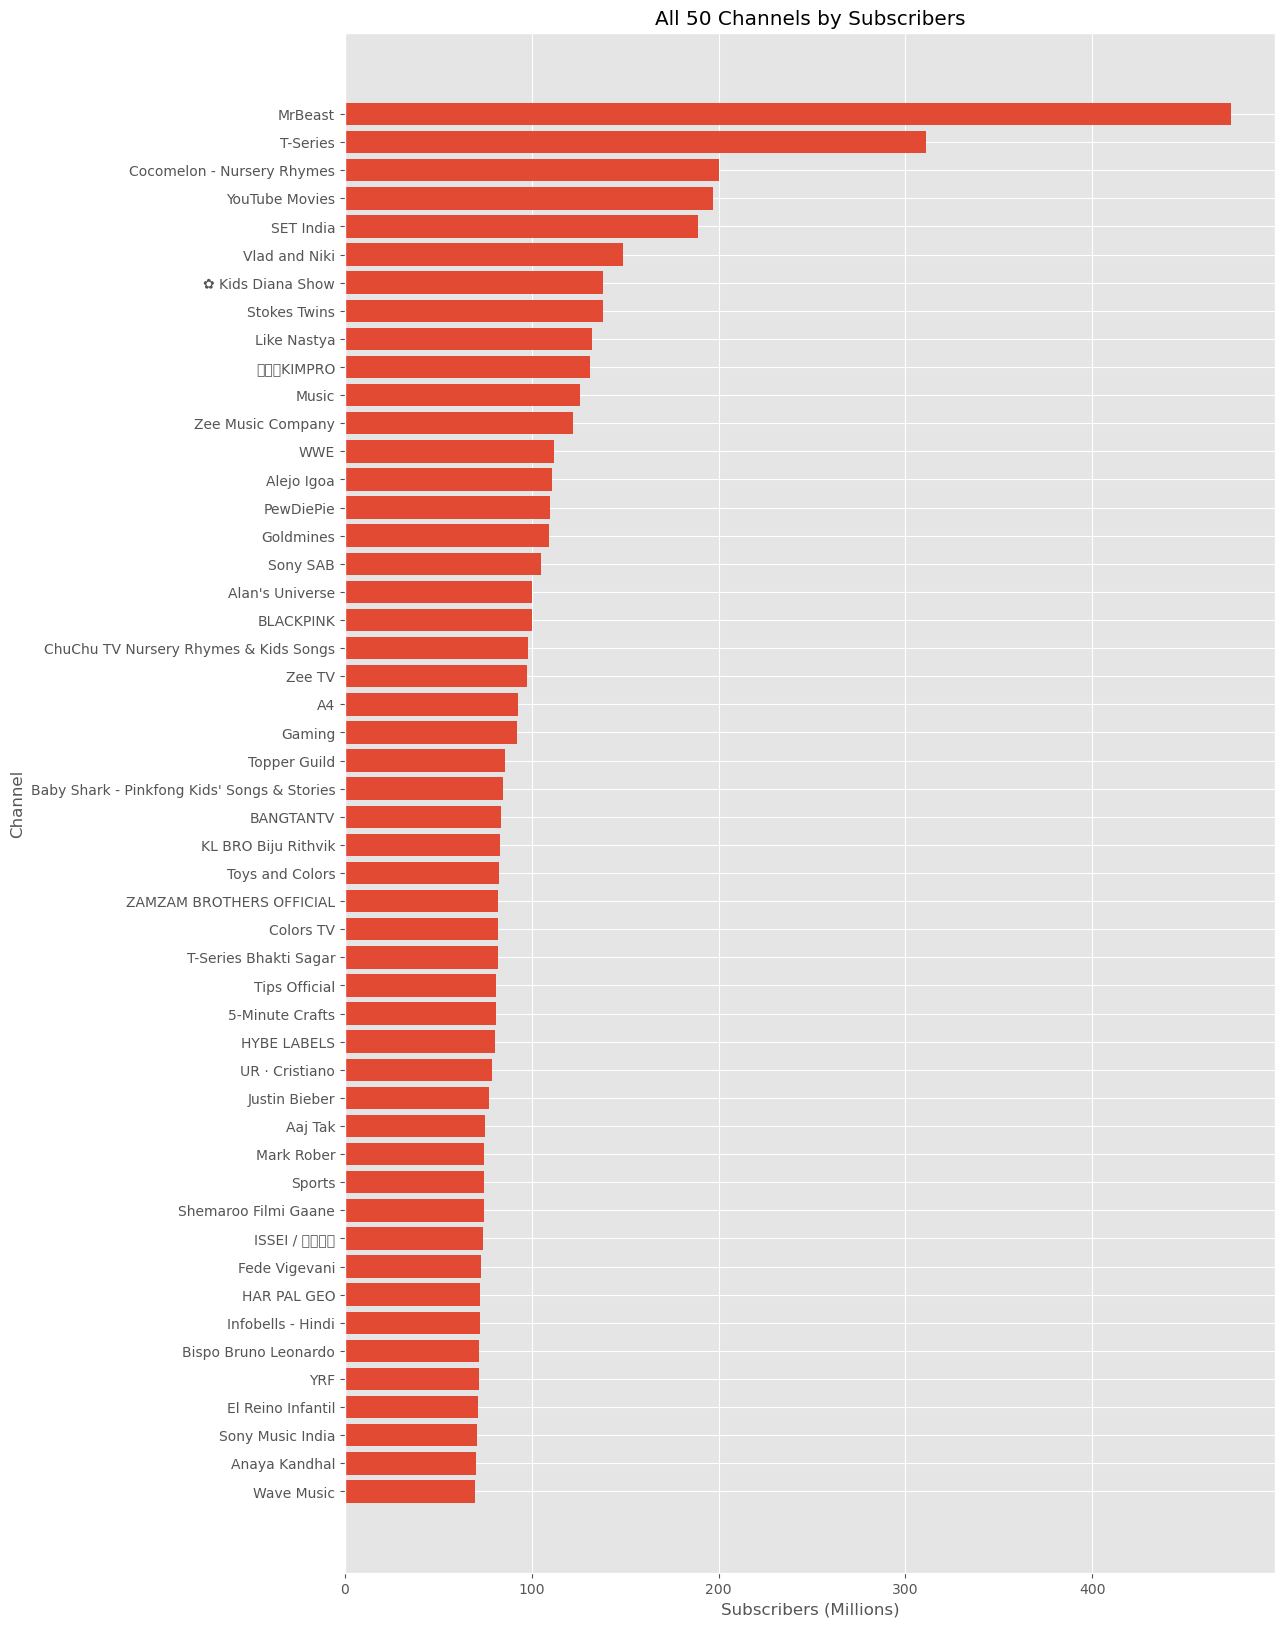

In [8]:
df_sorted_subs = df.sort_values(by='subscribers', ascending=True)

plt.figure(figsize=(12,20))
plt.barh(df_sorted_subs['channel'], df_sorted_subs['subscribers'])
plt.title("All 50 Channels by Subscribers")
plt.xlabel("Subscribers (Millions)")
plt.ylabel("Channel")
plt.show()

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


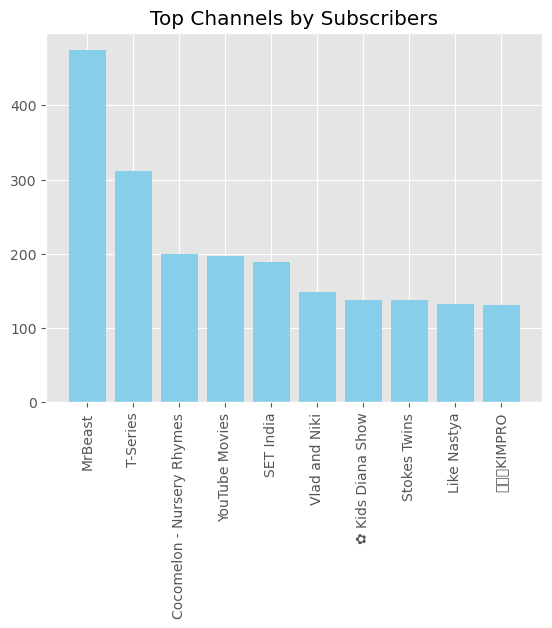

In [4]:

top_subs = df.sort_values(by='subscribers', ascending=False).head(10)

plt.figure()
plt.bar(top_subs['channel'], top_subs['subscribers'], color='skyblue')
plt.xticks(rotation=90)
plt.title("Top Channels by Subscribers")
plt.show()


## Top Channels by Views

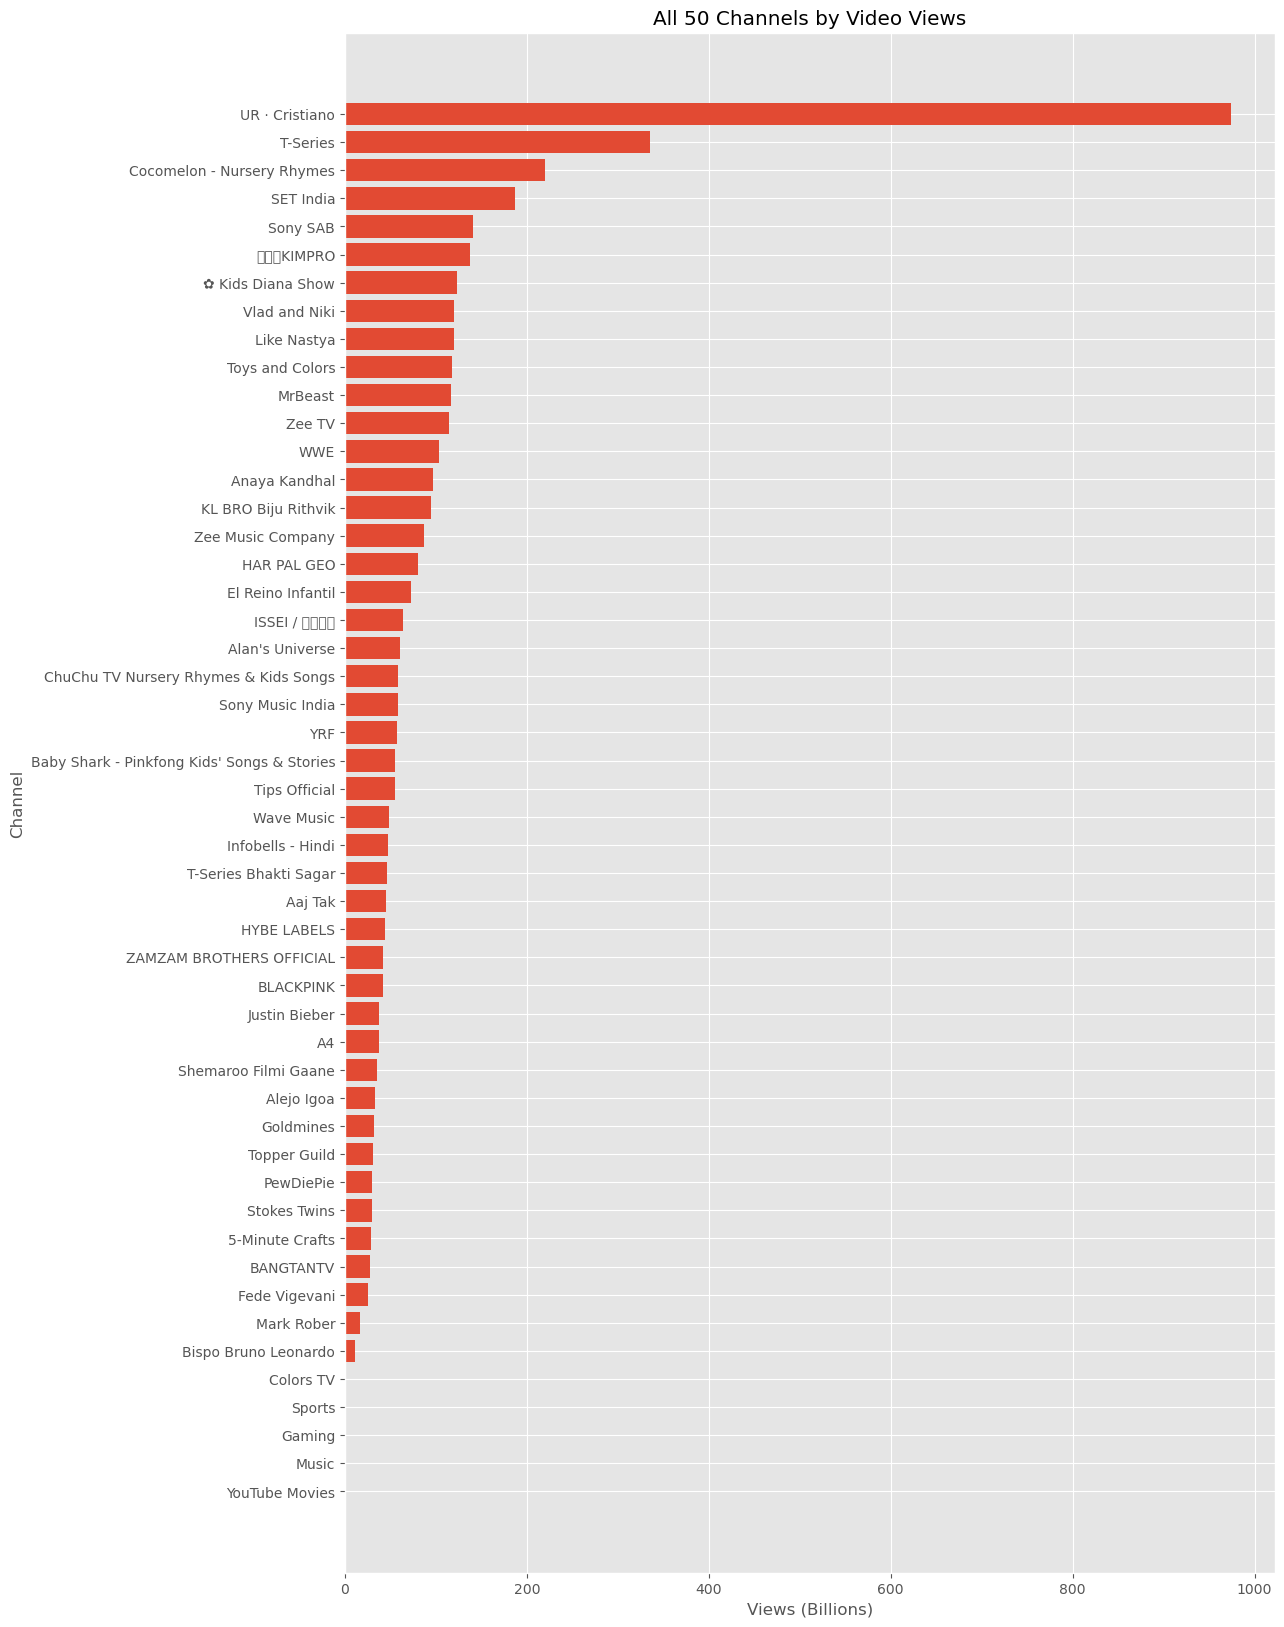

In [9]:
df_sorted_views = df.sort_values(by='video_views', ascending=True)

plt.figure(figsize=(12,20))
plt.barh(df_sorted_views['channel'], df_sorted_views['video_views'])
plt.title("All 50 Channels by Video Views")
plt.xlabel("Views (Billions)")
plt.ylabel("Channel")
plt.show()

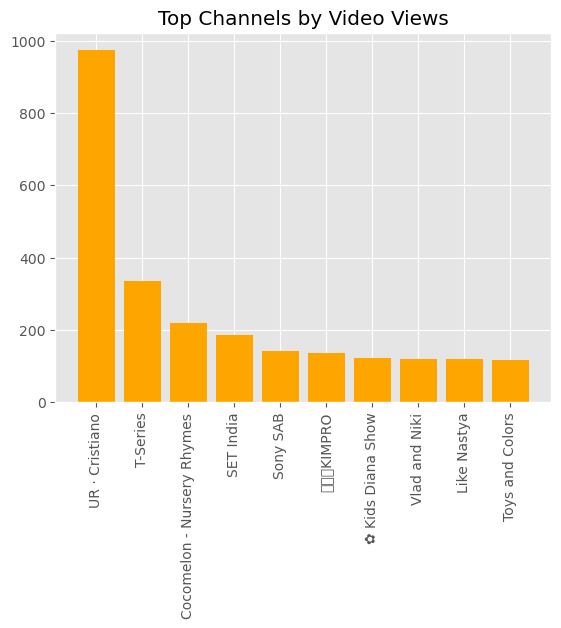

In [5]:

top_views = df.sort_values(by='video_views', ascending=False).head(10)

plt.figure()
plt.bar(top_views['channel'], top_views['video_views'], color='orange')
plt.xticks(rotation=90)
plt.title("Top Channels by Video Views")
plt.show()


## Uploads vs Subscribers

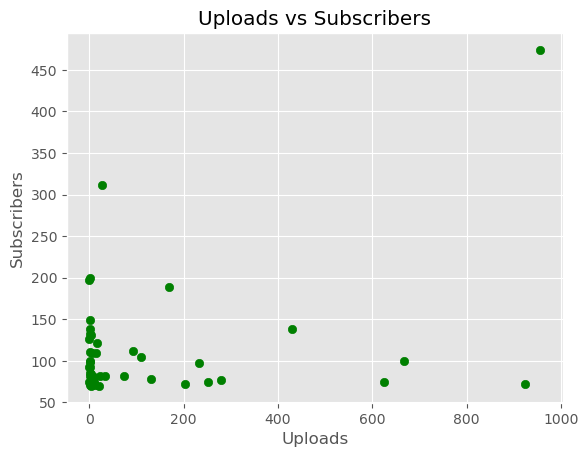

In [6]:

plt.figure()
plt.scatter(df['uploads'], df['subscribers'], color='green')
plt.xlabel("Uploads")
plt.ylabel("Subscribers")
plt.title("Uploads vs Subscribers")
plt.show()


## Correlation Matrix

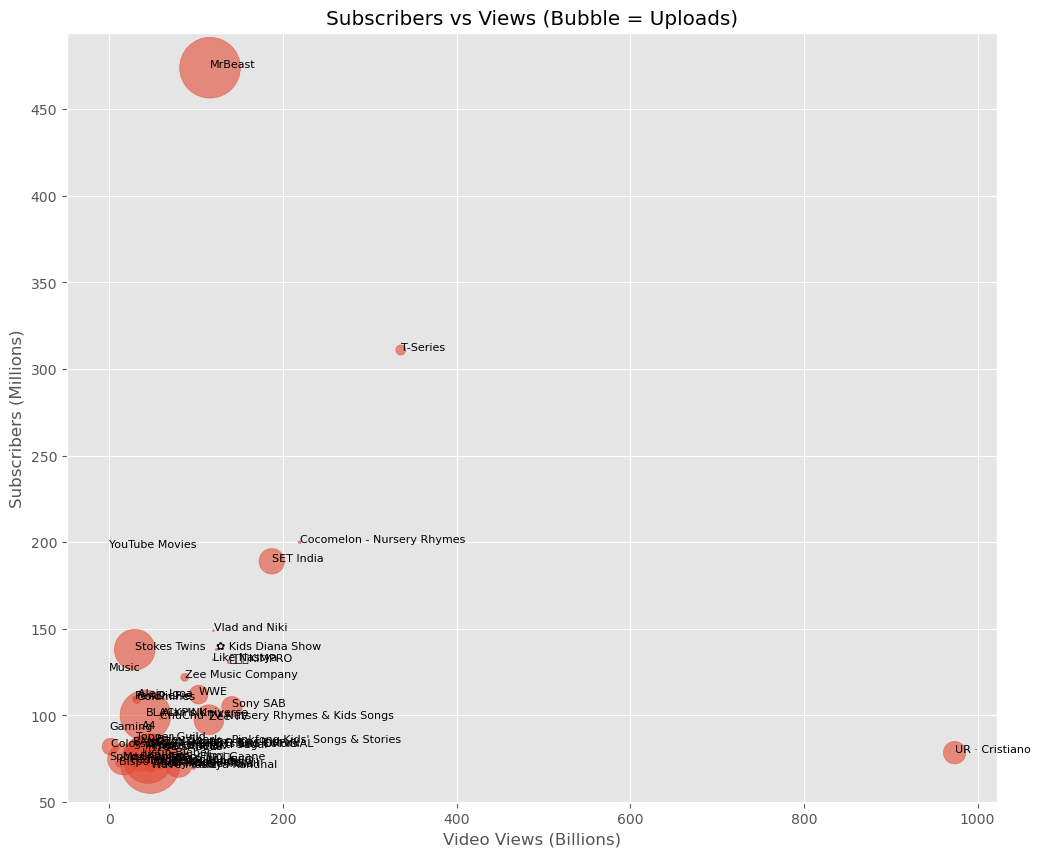

In [13]:
plt.figure(figsize=(12,10))

plt.scatter(
    df['video_views'], 
    df['subscribers'], 
    s=df['uploads']*2,   # bubble size
    alpha=0.6
)

plt.xlabel("Video Views (Billions)")
plt.ylabel("Subscribers (Millions)")
plt.title("Subscribers vs Views (Bubble = Uploads)")

for i in range(len(df)):
    plt.text(df['video_views'][i], df['subscribers'][i], df['channel'][i], fontsize=8)

plt.show()

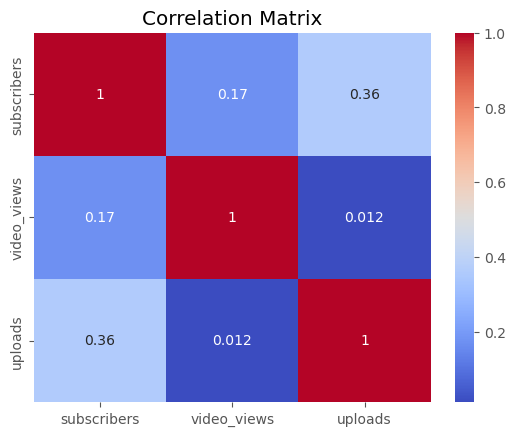

In [10]:

corr = df[['subscribers','video_views','uploads']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12387 (\N{HIRAGANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12379 (\N{HIRAGA

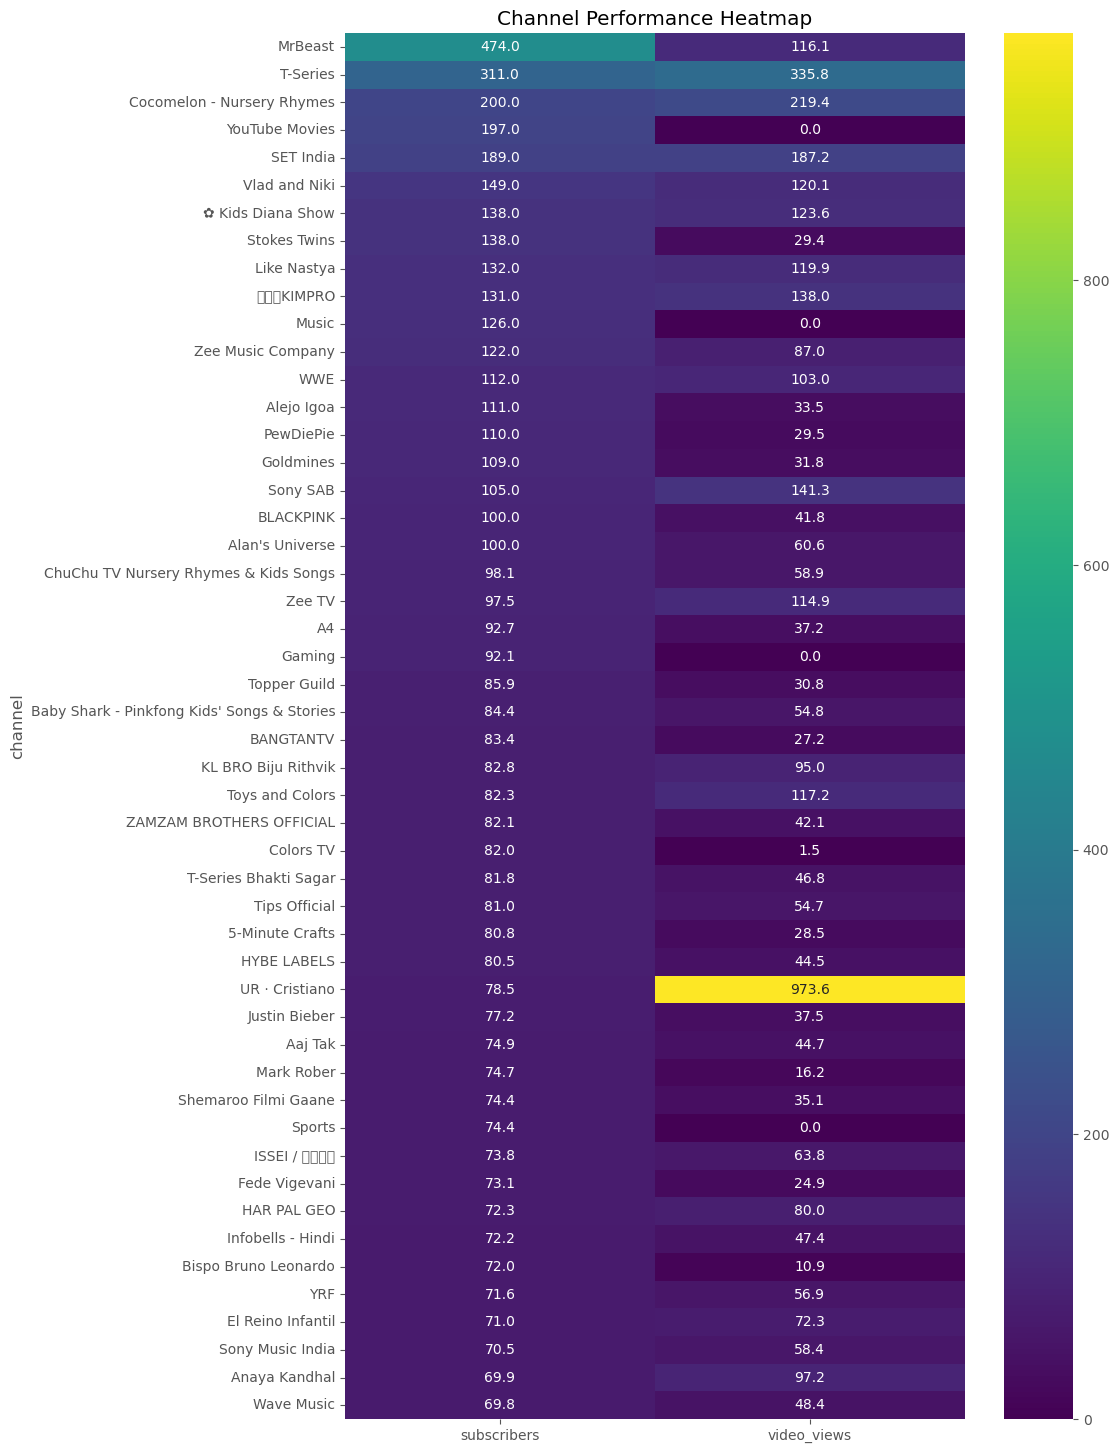

In [14]:
pivot = df[['channel', 'subscribers', 'video_views']].set_index('channel')

import seaborn as sns

plt.figure(figsize=(10,18))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt=".1f")

plt.title("Channel Performance Heatmap")
plt.show()